## Notebook 2: GRIDS / MASKS 

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [33]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [34]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [35]:
cfg  = C.get("cfg")     # dict loaded from YAML

In [36]:
# City-agnostic required inputs
required = [
    P(cfg["files"]["gvi_csv"]),
    P("UrbClim/UrbClimWBGTmax/WBGT_year_daily_max_2014.nc"),
    P("CAPZONE/CAPZONE.shp"),
    P("hazard"),
    P("worldpop"),
    P("fua"), 
]
missing = [p for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Some inputs are missing. Run Notebook 1 (Drive sync) first:\n" +
        "\n".join(str(p) for p in missing)
)

In [37]:
import geopandas as gpd

p_FUA = P("fua")
candidates = sorted(p_FUA.glob("*.geojson")) + sorted(p_FUA.glob("*.gpkg")) + sorted(p_FUA.glob("*.shp"))
candidates = [p for p in candidates if SLUG in p.stem.lower()] or candidates
assert candidates, f"No FUA file found in {p_FUA}"
fua_path = candidates[0]

fua = gpd.read_file(fua_path)
if fua.empty:
    raise ValueError("Loaded FUA is empty.")

## T2M Mean Daily Temperature 

> **T2M mean daily temperature:**
> - Loading historical daily T2M (kelvin) and build "typical day" baseline
> - Read monthly deltas for each projected target year
> - Build future daily series from baseline + monthly deltas
> - Mask for city's FUA on UrbClim grid
> - Apply mask and convert to °C

In [38]:
# Future DAILY T2M for 2030/2040/2050 (UrbClim + monthly change °C), masked to FUA and saved in °C
import os
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import geopandas as gpd
from affine import Affine
import rasterio.features as rfeat
from rasterio.crs import CRS

# Baseline climatology (2008–2017) on UrbClim grid 
t2m_dir   = P("UrbClim/UrbClimT2Mmean")
t2m_files = sorted(t2m_dir.glob("T2M_year_daily_mean_*.nc"))
assert t2m_files, "No T2M_year_daily_mean_*.nc files found."
ds = xr.open_mfdataset(t2m_files, combine="by_coords", decode_times=True)
vname = next((v for v in ("T2M","t2m","tas","temperature") if v in ds.data_vars), list(ds.data_vars)[0])
daK = ds[vname]  # (time,y,x), K

md_clim = daK.groupby("time.month").map(lambda grp: grp.groupby("time.day").mean("time"))
md_clim = md_clim.reindex(day=np.arange(1, 32)).ffill("day")

# grid axes (safe to use after ds.close)
x = md_clim["x"].values
y = md_clim["y"].values
ds.close()

# deltas CSV discovery 
MONTHS_EN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
delta_dir = P("T2MmeanDeltas")
deltas_cfg = (cfg.get("files", {}) or {}).get("t2m_deltas_csv", {})
wanted_years = (2030, 2040, 2050)

def _pick_delta_path(year: int) -> Path:
    if str(year) in deltas_cfg:
        p = delta_dir / deltas_cfg[str(year)]
        if p.exists():
            return p
    city_caps = [cfg.get("city_name", CITY), CITY, SLUG, SLUG.capitalize()]
    patterns = [
        f"T2_mean_*_{year}.csv",
        f"T2M_mean_*_{year}.csv",
        f"T2_mean_{CITY}_{year}.csv",
        f"T2M_mean_{CITY}_{year}.csv",
    ]
    for city in city_caps:
        for pat in patterns:
            for cand in sorted(delta_dir.glob(pat.replace("*", city))):
                return cand
    fallback = sorted(delta_dir.glob(f"*{year}.csv"))
    if fallback:
        return fallback[0]
    raise FileNotFoundError(f"No monthly delta CSV found for {year} in {delta_dir}")

delta_csv = {yr: _pick_delta_path(yr) for yr in wanted_years}
for y_, f_ in delta_csv.items():
    print(f"ΔT file {y_}: {f_}")

def read_monthly_delta_C(csv_path: Path) -> np.ndarray:
    df = pd.read_csv(csv_path)
    assert all(m in df.columns for m in MONTHS_EN), f"{csv_path.name}: need Jan..Dec columns"
    return df.loc[df.index[0], MONTHS_EN].astype(float).to_numpy()

# building future daily from baseline + monthly deltas 
def build_future_daily(yr: int, md_baseK: xr.DataArray, month_deltaC: np.ndarray) -> xr.DataArray:
    times = pd.date_range(f"{yr}-01-01", f"{yr}-12-31", freq="D")
    months = []
    for m in range(1, 13):
        ndays = int((times.month == m).sum())
        base_md = md_baseK.sel(month=m).isel(day=slice(0, ndays))
        fut_md  = base_md + float(month_deltaC[m-1])  # add °C to K (same increment)
        months.append(fut_md)
    futK = xr.concat(months, dim="day").rename({"day":"time"}).assign_coords(time=times)
    futK.name = "T2M"
    return futK.assign_attrs(units="K")

# FUA mask on the same (x,y) grid, EPSG:3035 
p_FUA = P("fua")
fua_path = (sorted(p_FUA.glob("*.geojson")) + sorted(p_FUA.glob("*.gpkg")) + sorted(p_FUA.glob("*.shp")))[0]
fua = gpd.read_file(fua_path).to_crs(CRS.from_epsg(3035))

dx = float(abs(np.diff(x).mean()))
dy = float(abs(np.diff(y).mean()))
transform = Affine.translation(float(x.min()) - dx/2,
                               float(y.max()) + dy/2) * Affine.scale(dx, -dy)

fua_mask = rfeat.geometry_mask(
    [g for g in fua.geometry if g is not None],
    out_shape=(len(y), len(x)),
    transform=transform,
    invert=True
)
fua_mask_da = xr.DataArray(fua_mask, coords={"y": y, "x": x}, dims=("y", "x"))

# I saved like this because I had a problem saving before: sometimes the drive synch creates problems
def robust_save(da: xr.DataArray, out_nc: Path):
    out_nc = str(out_nc)
    if os.path.exists(out_nc):
        try:
            os.chmod(out_nc, 0o644)
            os.remove(out_nc)
        except Exception as e:
            raise RuntimeError(f"Close any app using {out_nc} and retry. ({e})")
    tmp = out_nc + ".tmp"
    try:
        da.to_dataset(name=da.name or "T2M").to_netcdf(tmp, mode="w", engine="netcdf4")
        os.replace(tmp, out_nc)
    except Exception:
        try:
            if os.path.exists(tmp): os.remove(tmp)
        except Exception:
            pass
        da.to_dataset(name=da.name or "T2M").to_netcdf(tmp, mode="w", engine="scipy")
        os.replace(tmp, out_nc)

# computing and saving per year (masked °C)
zeros = np.zeros(12)
for year in (2030, 2040, 2050):
    dmC = read_monthly_delta_C(delta_csv[year])

    futK = build_future_daily(year, md_clim, dmC)
    futC = (futK.where(fua_mask_da) - 273.15).astype("float32")
    futC.name = "T2M"
    futC = futC.assign_attrs(units="degC", source_units="K")

    baseK_samecal = build_future_daily(year, md_clim, zeros)
    baseC_samecal = (baseK_samecal.where(fua_mask_da) - 273.15)

    base_monthC = baseC_samecal.groupby("time.month").mean(("time","y","x")).values
    fut_monthC  = futC.groupby("time.month").mean(("time","y","x")).values

    print(f"\n{year} city-mean monthly (°C) — base(same cal) | delta | future")
    for m in range(12):
        print(f"{m+1:02d}: {base_monthC[m]:6.2f} | {dmC[m]:+6.2f} | {fut_monthC[m]:6.2f}")

    out_nc = OUTP(f"hazard/T2M_daily_mean_{year}_FUA_degC.nc")
    robust_save(futC, out_nc)
    print(f"Saved {out_nc}")

ΔT file 2030: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/T2MmeanDeltas/T2M_mean_Rome_2030.csv
ΔT file 2040: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/T2MmeanDeltas/T2M_mean_Rome_2040.csv
ΔT file 2050: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/T2MmeanDeltas/T2M_mean_Rome_2050.csv

2030 city-mean monthly (°C) — base(same cal) | delta | future
01:   8.24 |  +0.36 |   8.59
02:   8.53 |  +0.34 |   8.86
03:  11.16 |  +0.27 |  11.43
04:  14.71 |  +0.29 |  15.00
05:  18.42 |  +0.32 |  18.73
06:  23.09 |  +0.37 |  23.46
07:  26.17 |  +0.47 |  26.64
08:  26.64 |  +0.44 |  27.08
09:  21.86 |  +0.49 |  22.34
10:  17.54 |  +0.37 |  17.91
11:  13.28 |  +0.23 |  13.51
12:   9.11 |  +0.33 |   9.45
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/hazard/T2M_daily_mean_2030_FUA_degC.nc

2040 city-mean monthly (°C) — base(same cal) | delta | future
01:   8.24 |  +0.48 |   8.72
02:   8.61 |

In [39]:
# Ref grid = UrbClim T2M grid (EPSG:3035) (exactly as our WBGT grid before)
import xarray as xr
from affine import Affine
from rasterio.crs import CRS

# using any of T2M outputs we saved (2030/2040/2050 all share the grid)
t2m_ref_nc = OUTP("hazard/T2M_daily_mean_2030_FUA_degC.nc")
ds_ref = xr.open_dataset(t2m_ref_nc)
da_ref = ds_ref["T2M"].isel(time=0)      # (y,x) slice on the UrbClim grid

x = da_ref["x"].values
y = da_ref["y"].values
dx = float(abs(np.diff(x).mean()))
dy = float(abs(np.diff(y).mean()))

ref_transform = Affine.translation(float(x.min()) - dx/2,
                                   float(y.max()) + dy/2) * Affine.scale(dx, -dy)

ref_crs       = CRS.from_epsg(3035)      # UrbClim T2M is on LAEA Europe
ref_shape     = (da_ref.sizes["y"], da_ref.sizes["x"])

ref_meta = {
    "crs": ref_crs,
    "transform": ref_transform,
    "height": ref_shape[0],
    "width":  ref_shape[1],
    "dtype": "float32",
}

ref_data = da_ref.values   # contains NaNs outside FUA

**Age-grouped** WorldPop data

In [40]:
# Helper: read a raster, reproject FUA to its CRS, mask+crop to FUA, return array+metadata
import numpy as np
import rasterio as rio
from rasterio.mask import mask as rio_mask

def read_and_mask_to_fua(raster_path, fua_gdf):
    with rio.open(raster_path) as src:
        src_crs = src.crs
        fua_in_src = fua_gdf.to_crs(src_crs)
        geoms = [g for g in fua_in_src.geometry if g is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty/invalid.")
        out, out_transform = rio_mask(
            src, geoms, crop=True, filled=True, nodata=np.nan
        )
        meta = src.meta.copy()
        meta.update(height=out.shape[1], width=out.shape[2], transform=out_transform)
        data = out[0].astype(float)
    return data, out_transform, src_crs, meta

In [41]:
# WorldPop age groups on native grid, then onto T2M ref grid 

from rasterio.warp import reproject
from rasterio.enums import Resampling
import numpy as np
import rasterio as rio
import geopandas as gpd

year    = 2030
release = "R2025A"
version = "v1"
gender  = "t"

AGE_GROUPS = {
    "<15":   ["00", "01", "05", "10"],
    "15-64": ["15","20","25","30","35","40","45","50","55","60"],
    "65+":   ["65","70","75","80","85","90"],
}
ALL_CODES = [c for L in AGE_GROUPS.values() for c in L]

def worldpop_age_path(code):
    patt = f"ita_{gender}_{code}_{year}_CN_100m_{release}_{version}.tif*"
    candidates = sorted((P("worldpop")).rglob(patt))  # search recursively
    if not candidates:
        raise FileNotFoundError(f"No WorldPop file matching: {patt} under {P('worldpop')}")
    return candidates[0]

def build_age_group_rasters(fua_gdf):
    agg = {"<15": None, "15-64": None, "65+": None}
    wp_meta = None
    for code in ALL_CODES:
        arr, _, _, meta = read_and_mask_to_fua(worldpop_age_path(code), fua_gdf)
        arr = np.nan_to_num(arr, nan=0.0).astype(np.float32)
        if wp_meta is None:
            wp_meta = meta
        for grp, codes in AGE_GROUPS.items():
            if code in codes:
                agg[grp] = arr if agg[grp] is None else (agg[grp] + arr)
                break
    for k, v in agg.items():
        if v is None:
            agg[k] = np.zeros_like(next(x for x in agg.values() if x is not None), dtype=np.float32)
    return agg, wp_meta

age_native, wp_meta = build_age_group_rasters(fua)

print("Native-grid totals within FUA (people):")
for k, v in age_native.items():
    print(f"  {k:>5}: {float(v.sum()):,.0f}")

def reproject_sum_to_ref(src_arr, src_meta, ref_meta, ref_like):
    out = np.zeros_like(ref_like, dtype=float)
    reproject(
        source=np.nan_to_num(src_arr, nan=0.0),
        destination=out,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.sum,
        src_nodata=0.0,
        dst_nodata=0.0,
    )
    return np.where(np.isfinite(ref_like), out, 0.0)

# total pop then age bands on ref grid
pop_native = sum(np.nan_to_num(v, nan=0.0) for v in age_native.values())
pop_on_ref = reproject_sum_to_ref(pop_native, wp_meta, ref_meta, ref_data)

age_on_ref = {
    grp: reproject_sum_to_ref(arr, wp_meta, ref_meta, ref_data)
    for grp, arr in age_native.items()
}

native_total = float(pop_native.sum())
ref_total    = float(pop_on_ref.sum())
print("\nPopulation totals (people):")
print(f"  WP-native sum over FUA  : {native_total:,.0f}")
print(f"  T2M-grid sum (reproj): {ref_total:,.0f}")

Native-grid totals within FUA (people):
    <15: 399,821
  15-64: 2,251,596
    65+: 952,085

Population totals (people):
  WP-native sum over FUA  : 3,603,501
  T2M-grid sum (reproj): 2,548,154


In [42]:
assert pop_on_ref.shape == (ref_meta["height"], ref_meta["width"]), "Pop grid != ref grid shape"
for k, a in age_on_ref.items():
    assert a.shape == pop_on_ref.shape, f"Age band {k} shape != ref grid"

In [43]:
# defining mask for later
CITY_MASK = np.isfinite(ref_data) & (pop_on_ref > 0) # main analysis mask         

# Consistency check: do age bands add up to pop_on_ref?
pop_from_ages = np.zeros_like(pop_on_ref, dtype=float)
for a in age_on_ref.values():
    pop_from_ages += np.nan_to_num(a)

abs_diff = float(np.abs(np.nansum(pop_from_ages) - np.nansum(pop_on_ref)))
rel_diff = abs_diff / max(np.nansum(pop_on_ref), 1.0)

print("\nSanity check — totals on T2M grid (people):")
for k, v in age_on_ref.items():
    print(f"  {k:>5}: {float(np.nansum(v)):.0f}")
print(f"  Sum(age bands): {float(np.nansum(pop_from_ages)):.0f}") # yes it does
print(f"  pop_on_ref    : {float(np.nansum(pop_on_ref)):.0f}")
print(f"  Abs diff      : {abs_diff:.3f}  ({100*rel_diff:.4f}%)")


Sanity check — totals on T2M grid (people):
    <15: 277144
  15-64: 1580341
    65+: 690669
  Sum(age bands): 2548154
  pop_on_ref    : 2548154
  Abs diff      : 0.001  (0.0000%)


In [44]:
import json
with open(INT / "exposure_meta.json", "w") as f:
    json.dump({"worldpop_year": 2030}, f)

In [45]:
# some stat on T2M hazard 
import numpy as np, xarray as xr

years = (2030, 2040, 2050)

def load_t2m(year):
    ds = xr.open_dataset(OUTP(f"hazard/T2M_daily_mean_{year}_FUA_degC.nc"))
    return ds["T2M"]  # (time,y,x) in °C, NaN outside FUA

print("T2M annual-mean (°C) — city distribution over FUA pixels")
for y in years:
    da = load_t2m(y)
    annual_mean = da.mean("time")                       
    v = annual_mean.values[np.isfinite(annual_mean)]    
    print(f"{y}: min={np.min(v):.2f}, median={np.median(v):.2f}, p95={np.percentile(v,95):.2f}, max={np.max(v):.2f}")

T2M annual-mean (°C) — city distribution over FUA pixels
2030: min=13.75, median=16.98, p95=18.06, max=18.38
2040: min=13.91, median=17.14, p95=18.21, max=18.54
2050: min=14.11, median=17.35, p95=18.42, max=18.75


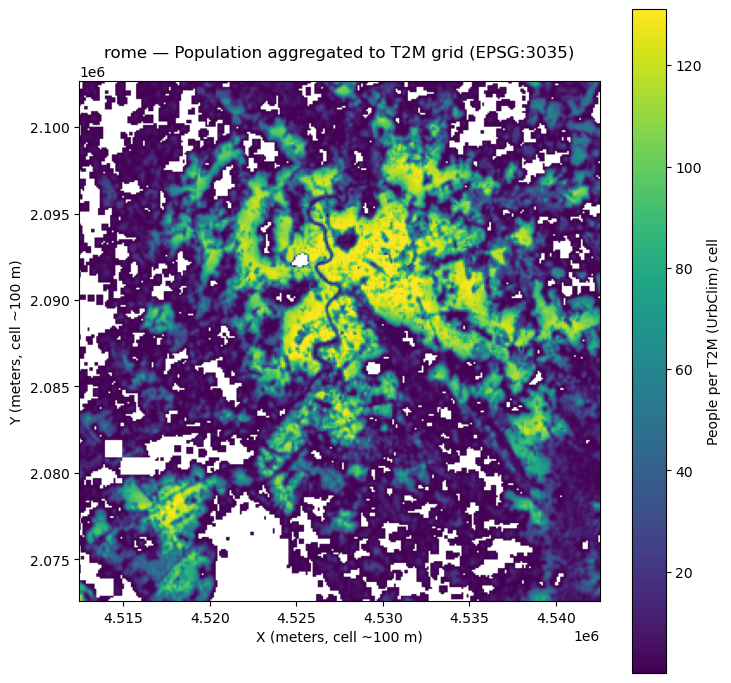

In [46]:
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds
import numpy as np

plot_arr = np.where(CITY_MASK, pop_on_ref, np.nan)
h, w = plot_arr.shape
left, bottom, right, top = array_bounds(h, w, ref_meta["transform"])

vmax   = np.nanpercentile(plot_arr, 99)
origin = 'upper' if ref_meta["transform"].e < 0 else 'lower'  

plt.figure(figsize=(7.5, 7))
im = plt.imshow(
    plot_arr,
    extent=(left, right, bottom, top),
    origin=origin,
    vmax=vmax,
)
cb = plt.colorbar(im); cb.set_label("People per T2M (UrbClim) cell")

ax = plt.gca()
ax.set_xlim(left, right)
ax.set_ylim(bottom, top)          
if ax.yaxis_inverted():          
    ax.invert_yaxis()            

dx = ref_meta["transform"].a
dy = abs(ref_meta["transform"].e)
plt.title(f"{CITY} — Population aggregated to T2M grid (EPSG:3035)")
plt.xlabel(f"X (meters, cell ~{dx:.0f} m)")
plt.ylabel(f"Y (meters, cell ~{dy:.0f} m)")
ax.set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

**Saving for later**

In [47]:
import json, numpy as np, rasterio as rio
from rasterio.crs import CRS

# saving ref grid metadata (UrbClim T2M grid, EPSG:3035) 
epsg = ref_meta["crs"].to_epsg()
ref_meta_slim = {
    "crs_epsg": int(epsg) if epsg is not None else None,
    "crs_wkt": ref_meta["crs"].to_wkt(),
    "transform": list(ref_meta["transform"]),  # Affine -> list for JSON
    "width": int(ref_meta["width"]),
    "height": int(ref_meta["height"]),
}
(INT).mkdir(parents=True, exist_ok=True)
with open(INT / "ref_meta.json", "w") as f:
    json.dump(ref_meta_slim, f, indent=2)

# blank GeoTIFF template with the same georeferencing
tmpl_path = INT / "template_ref.tif"
profile = {**ref_meta, "dtype": "float32", "count": 1, "nodata": np.float32(np.nan)}
with rio.open(tmpl_path, "w", **profile) as dst:
    dst.write(np.full((ref_meta["height"], ref_meta["width"]), np.nan, dtype="float32"), 1)

# saving city mask (inside FUA) 
np.savez_compressed(INT / "city_mask.npz", city_mask=CITY_MASK.astype(np.uint8))
with rio.open(INT / "city_mask.tif", "w", **{**profile, "dtype": "uint8", "nodata": 0}) as dst:
    dst.write(CITY_MASK.astype("uint8"), 1)

# saving FUA geometry 
fua_out = OUT / f"{SLUG}_fua.gpkg"
fua.to_file(fua_out, layer="fua", driver="GPKG")

# Hazard manifest for the new T2M daily mean (degC, masked to FUA) 
t2m_nc_paths = {
    2030: str(OUTP("hazard/T2M_daily_mean_2030_FUA_degC.nc")),
    2040: str(OUTP("hazard/T2M_daily_mean_2040_FUA_degC.nc")),
    2050: str(OUTP("hazard/T2M_daily_mean_2050_FUA_degC.nc")),
}
haz_manifest = {
    "slug": SLUG,
    "hazard_type": "t2m_daily_mean",
    "units": "degC",
    "grid_crs_epsg": int(epsg) if epsg is not None else None,
    "variable_name": "T2M",
    "files": {str(y): p for y, p in t2m_nc_paths.items()},
}
with open(INT / "hazard_manifest.json", "w") as f:
    json.dump(haz_manifest, f, indent=2)

# Exposure arrays on reference grid (npz) 
np.savez_compressed(INT / f"age_on_ref_{SLUG}.npz",
    lt15   = age_on_ref["<15"].astype("float32"),
    a15_64 = age_on_ref["15-64"].astype("float32"),
    g65    = age_on_ref["65+"].astype("float32"),
)
np.savez_compressed(INT / f"pop_on_ref_{SLUG}.npz",
    pop = pop_on_ref.astype("float32"),
)

# GeoTIFFs 
gt_profile = {**ref_meta, "dtype": "float32", "count": 1, "nodata": np.float32(np.nan)}
with rio.open(INT / "pop_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(pop_on_ref.astype("float32"), 1)
with rio.open(INT / "age_lt15_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["<15"].astype("float32"), 1)
with rio.open(INT / "age_15_64_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["15-64"].astype("float32"), 1)
with rio.open(INT / "age_65p_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["65+"].astype("float32"), 1)

print("Saved:",
      INT / "ref_meta.json",
      tmpl_path,
      INT / "city_mask.npz",
      INT / "city_mask.tif",
      INT / "hazard_manifest.json",
      OUT / f"{SLUG}_fua.gpkg",
      INT / f"age_on_ref_{SLUG}.npz",
      INT / f"pop_on_ref_{SLUG}.npz",
      INT / "pop_on_ref.tif",
      INT / "age_lt15_on_ref.tif",
      INT / "age_15_64_on_ref.tif",
      INT / "age_65p_on_ref.tif",
      sep="\n  - ")

Saved:
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ref_meta.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/template_ref.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/city_mask.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/city_mask.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_manifest.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/age_on_ref_rome.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/pop_on_ref_rome.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/pop_on_ref.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/